<a href="https://colab.research.google.com/github/BU-Spark/ds-ciss-predictive-homlessness/blob/data-cleaning-feature/Pat_Modeling_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### SPR 2025, This notebook contains the final code for the XGBoost model, ran on five target variables.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from xgboost import XGBRegressor



In [ ]:
file_path = '/content/CISS_final_df2.csv'
data = pd.read_csv(file_path)
data.head()


,CoC_Number,Year,weighted median income,weighted median rent,total population,CoC Name,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless Individuals,Overall Homeless People in Families,Poverty_Rate,Vacancy_Rate,Renter_Household_Rate,Cost_Burdened_Rate,Unemployment_Rate,Average Temperature,"Beds (ES, TH, SH)"
0,AK-500,2007,78328.533122,1062.638009,284267.0,Anchorage CoC,3.426356,2.962004,0.464352,2.448402,0.977954,8.298238,7.425172,40.858279,42.153397,7.583368,5.5,884.0
1,AK-500,2008,78328.533122,1062.638009,284267.0,Anchorage CoC,3.598729,3.239912,0.358818,2.444885,1.153845,8.298238,7.425172,40.858279,42.153397,7.583368,0.4,899.0
2,AK-500,2009,78328.533122,1062.638009,284267.0,Anchorage CoC,4.457077,3.904780,0.552298,2.888130,1.568948,8.298238,7.425172,40.858279,42.153397,7.583368,-0.2,877.0
3,AK-500,2010,78328.533122,1062.638009,284267.0,Anchorage CoC,4.330436,3.915333,0.415103,2.603186,1.727249,8.298238,7.425172,40.858279,42.153397,7.583368,1.5,990.0
4,AK-500,2011,80808.699781,1037.436470,287390.0,Anchorage CoC,4.255541,3.764919,0.490622,2.762796,1.492745,8.504627,7.073878,42.293547,42.845948,7.593841,7.0,1056.0


## Splitting data for XGBoost

- For every model, we select the numerical features of interest. We exclue columns such as Year, CoC_Name, and CoC_Number as they don't provide anything for training
- The Target columns of interest are: "Overall Homeless", "Sheltered Total Homeless", "Unsheltered Homeless", "Overall Homeless Individuals", and "Overall Homeless People in Families"



In [ ]:
columns_to_summarize = [
    'Overall Homeless',
    'Sheltered Total Homeless',
    'Unsheltered Homeless',
    'Overall Homeless Individuals',
    'Overall Homeless People in Families'
]

# Get the summary statistics
summary_stats = data[columns_to_summarize].describe()

# Display the summary statistics
print(summary_stats)

       Overall Homeless  Sheltered Total Homeless  Unsheltered Homeless  \
count       6386.000000               6386.000000           6386.000000   
mean           1.945576                  1.225897              0.719679   
std            2.040150                  1.189834              1.447777   
min            0.068500                  0.000000              0.000000   
25%            0.791237                  0.566101              0.081291   
50%            1.313376                  0.915774              0.218215   
75%            2.231352                  1.458187              0.650282   
max           23.786446                 12.187997             17.546817   

       Overall Homeless Individuals  Overall Homeless People in Families  
count                   6386.000000                          6386.000000  
mean                       1.302443                             0.641518  
std                        1.538570                             0.839576  
min                     

# Overall Homeless Model

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

features = [
    'weighted median income',
    'weighted median rent',
    'total population',
    'Poverty_Rate',
    'Vacancy_Rate',
    'Renter_Household_Rate',
    'Cost_Burdened_Rate',
    'Unemployment_Rate',
    'Average Temperature'
]
X = data[features]
y = data['Overall Homeless']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param_grid = {
    'n_estimators':      [100, 200, 500],
    'max_depth':         [2, 3],
    'learning_rate':     [0.01],
    'subsample':         [0.6, 0.8],
    'colsample_bytree':  [0.6, 0.8],
    'gamma':             [0, 1],
    'reg_alpha':         [0, 0.1, 1],
    'reg_lambda':        [1, 10]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse  = mean_squared_error(y_test,  y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse  = np.sqrt(test_mse)
train_mae  = mean_absolute_error(y_train, y_train_pred)
test_mae   = mean_absolute_error(y_test,  y_test_pred)
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)

print(f"Training Set MSE:       {train_mse:.2f}")
print(f"Training Set RMSE:      {train_rmse:.2f}")
print(f"Training Set MAE:       {train_mae:.2f}")
print(f"Training Set R-squared: {train_r2:.4f}")
print(f"Test Set MSE:           {test_mse:.2f}")
print(f"Test Set RMSE:          {test_rmse:.2f}")
print(f"Test Set MAE:           {test_mae:.2f}")
print(f"Test Set R-squared:     {test_r2:.4f}")


Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Training Set MSE:       1.64
Training Set RMSE:      1.28
Training Set MAE:       0.81
Training Set R-squared: 0.5781
Test Set MSE:           2.48
Test Set RMSE:          1.57
Test Set MAE:           0.92
Test Set R-squared:     0.5257


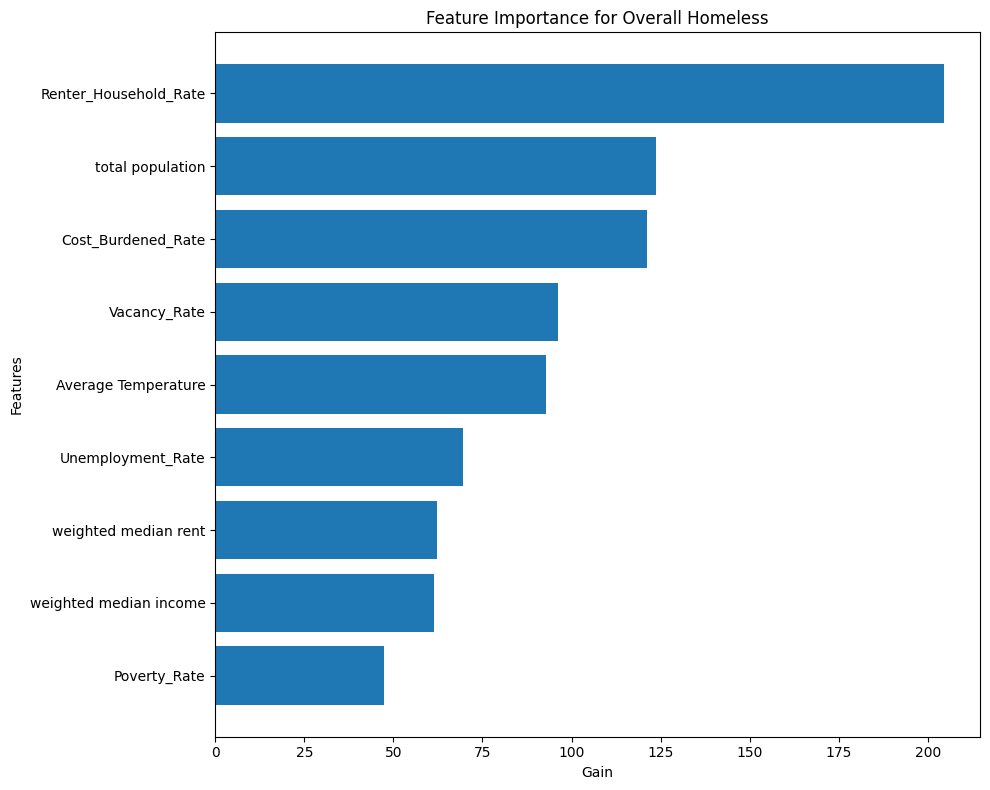

In [ ]:
# Feature importance by gain
gain_dict = best_model.get_booster().get_score(importance_type='gain')
gain_items = sorted(gain_dict.items(), key=lambda x: x[1])
feat_names, gain_values = zip(*gain_items)

plt.figure(figsize=(10, 8))
plt.barh(feat_names, gain_values)
plt.title("Feature Importance for Overall Homeless")
plt.xlabel("Gain")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Sheltered Homeless Model

In [ ]:
features = [
    'weighted median income',
    'weighted median rent',
    'total population',
    'Poverty_Rate',
    'Vacancy_Rate',
    'Renter_Household_Rate',
    'Cost_Burdened_Rate',
    'Unemployment_Rate',
    'Average Temperature'
]
X = data[features]
y = data['Sheltered Total Homeless']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param_grid = {
    'n_estimators':      [100, 200, 500],
    'max_depth':         [2, 3],
    'learning_rate':     [0.01],
    'subsample':         [0.6, 0.8],
    'colsample_bytree':  [0.6, 0.8],
    'gamma':             [0, 1],
    'reg_alpha':         [0, 0.1, 1],
    'reg_lambda':        [1, 10]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse  = mean_squared_error(y_test,  y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse  = np.sqrt(test_mse)
train_mae  = mean_absolute_error(y_train, y_train_pred)
test_mae   = mean_absolute_error(y_test,  y_test_pred)
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)

print(f"Training Set MSE:       {train_mse:.2f}")
print(f"Training Set RMSE:      {train_rmse:.2f}")
print(f"Training Set MAE:       {train_mae:.2f}")
print(f"Training Set R-squared: {train_r2:.4f}")
print(f"Test Set MSE:           {test_mse:.2f}")
print(f"Test Set RMSE:          {test_rmse:.2f}")
print(f"Test Set MAE:           {test_mae:.2f}")
print(f"Test Set R-squared:     {test_r2:.4f}")


Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Training Set MSE:       0.46
Training Set RMSE:      0.68
Training Set MAE:       0.45
Training Set R-squared: 0.6601
Test Set MSE:           0.75
Test Set RMSE:          0.87
Test Set MAE:           0.52
Test Set R-squared:     0.5540


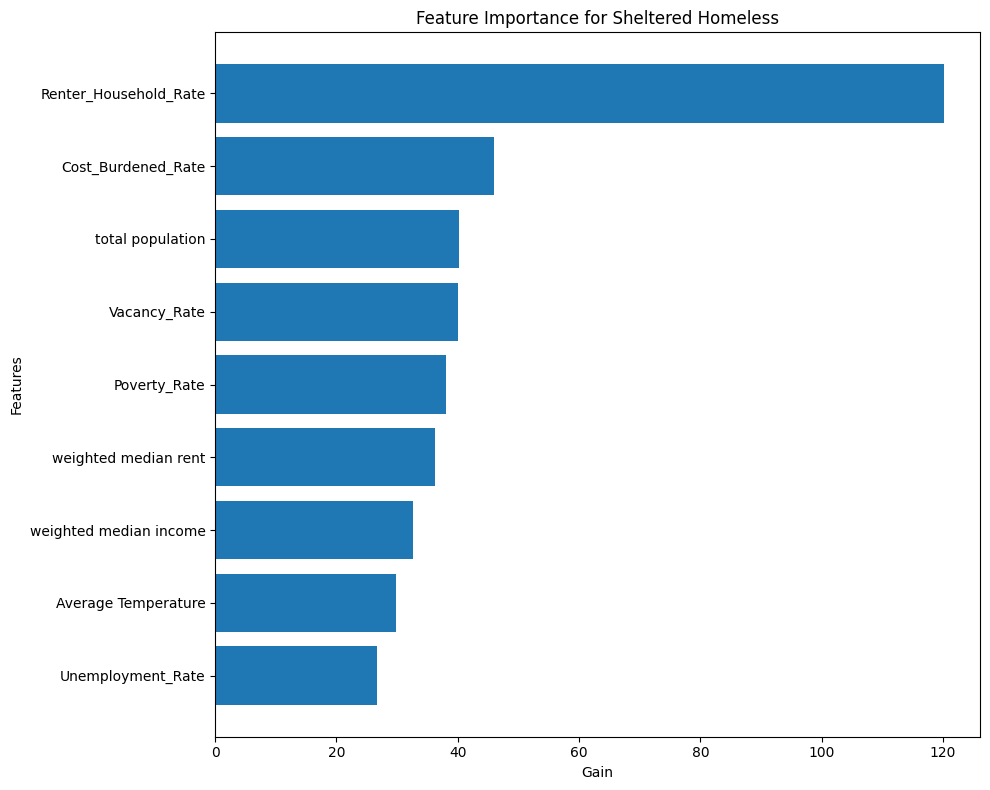

In [ ]:
# Feature Importance
gain_dict = best_model.get_booster().get_score(importance_type='gain')
gain_items = sorted(gain_dict.items(), key=lambda x: x[1])
feat_names, gain_values = zip(*gain_items)

plt.figure(figsize=(10, 8))
plt.barh(feat_names, gain_values)
plt.title("Feature Importance for Sheltered Homeless")
plt.xlabel("Gain")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Unsheltered Homeless Model

In [ ]:
features = [
    'weighted median income',
    'weighted median rent',
    'total population',
    'Poverty_Rate',
    'Vacancy_Rate',
    'Renter_Household_Rate',
    'Cost_Burdened_Rate',
    'Unemployment_Rate',
    'Average Temperature'
]
X = data[features]
y = data['Unsheltered Homeless']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param_grid = {
    'n_estimators':      [100, 200, 500],
    'max_depth':         [2, 3],
    'learning_rate':     [0.01],
    'subsample':         [0.6, 0.8],
    'colsample_bytree':  [0.6, 0.8],
    'gamma':             [0, 1],
    'reg_alpha':         [0, 0.1, 1],
    'reg_lambda':        [1, 10]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse  = mean_squared_error(y_test,  y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse  = np.sqrt(test_mse)
train_mae  = mean_absolute_error(y_train, y_train_pred)
test_mae   = mean_absolute_error(y_test,  y_test_pred)
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)

print(f"Training Set MSE:       {train_mse:.2f}")
print(f"Training Set RMSE:      {train_rmse:.2f}")
print(f"Training Set MAE:       {train_mae:.2f}")
print(f"Training Set R-squared: {train_r2:.4f}")
print(f"Test Set MSE:           {test_mse:.2f}")
print(f"Test Set RMSE:          {test_rmse:.2f}")
print(f"Test Set MAE:           {test_mae:.2f}")
print(f"Test Set R-squared:     {test_r2:.4f}")

Training Set MSE:       0.88
Training Set RMSE:      0.94
Training Set MAE:       0.48
Training Set R-squared: 0.5520
Test Set MSE:           1.33
Test Set RMSE:          1.15
Test Set MAE:           0.56
Test Set R-squared:     0.4915


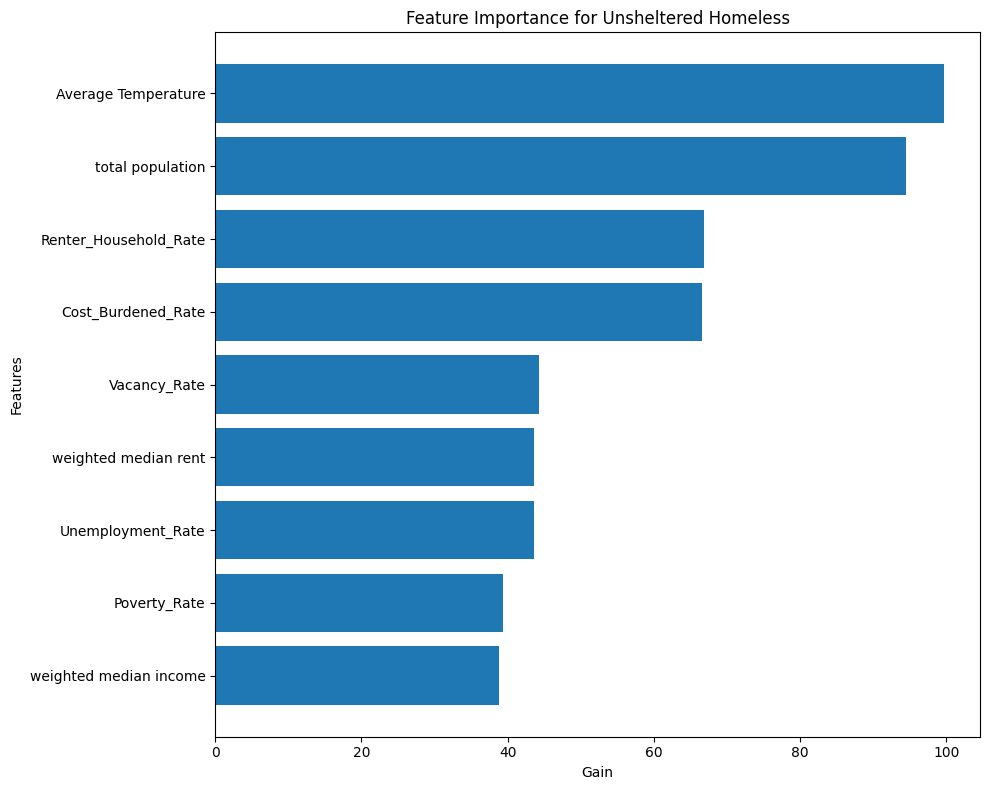

In [ ]:
# Feature Importance
gain_dict = best_model.get_booster().get_score(importance_type='gain')
gain_items = sorted(gain_dict.items(), key=lambda x: x[1])
feat_names, gain_values = zip(*gain_items)

plt.figure(figsize=(10, 8))
plt.barh(feat_names, gain_values)
plt.title("Feature Importance for Unsheltered Homeless")
plt.xlabel("Gain")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Overall Homeless Individuals

In [ ]:
features = [
    'weighted median income',
    'weighted median rent',
    'total population',
    'Poverty_Rate',
    'Vacancy_Rate',
    'Renter_Household_Rate',
    'Cost_Burdened_Rate',
    'Unemployment_Rate',
    'Average Temperature'
]
X = data[features]
y = data['Overall Homeless Individuals']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param_grid = {
    'n_estimators':      [100, 200, 500],
    'max_depth':         [2, 3],
    'learning_rate':     [0.01],
    'subsample':         [0.6, 0.8],
    'colsample_bytree':  [0.6, 0.8],
    'gamma':             [0, 1],
    'reg_alpha':         [0, 0.1, 1],
    'reg_lambda':        [1, 10]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse  = mean_squared_error(y_test,  y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse  = np.sqrt(test_mse)
train_mae  = mean_absolute_error(y_train, y_train_pred)
test_mae   = mean_absolute_error(y_test,  y_test_pred)
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)

print(f"Training Set MSE:       {train_mse:.2f}")
print(f"Training Set RMSE:      {train_rmse:.2f}")
print(f"Training Set MAE:       {train_mae:.2f}")
print(f"Training Set R-squared: {train_r2:.4f}")
print(f"Test Set MSE:           {test_mse:.2f}")
print(f"Test Set RMSE:          {test_rmse:.2f}")
print(f"Test Set MAE:           {test_mae:.2f}")
print(f"Test Set R-squared:     {test_r2:.4f}")

Training Set MSE:       0.87
Training Set RMSE:      0.94
Training Set MAE:       0.57
Training Set R-squared: 0.6080
Test Set MSE:           1.18
Test Set RMSE:          1.09
Test Set MAE:           0.64
Test Set R-squared:     0.5929


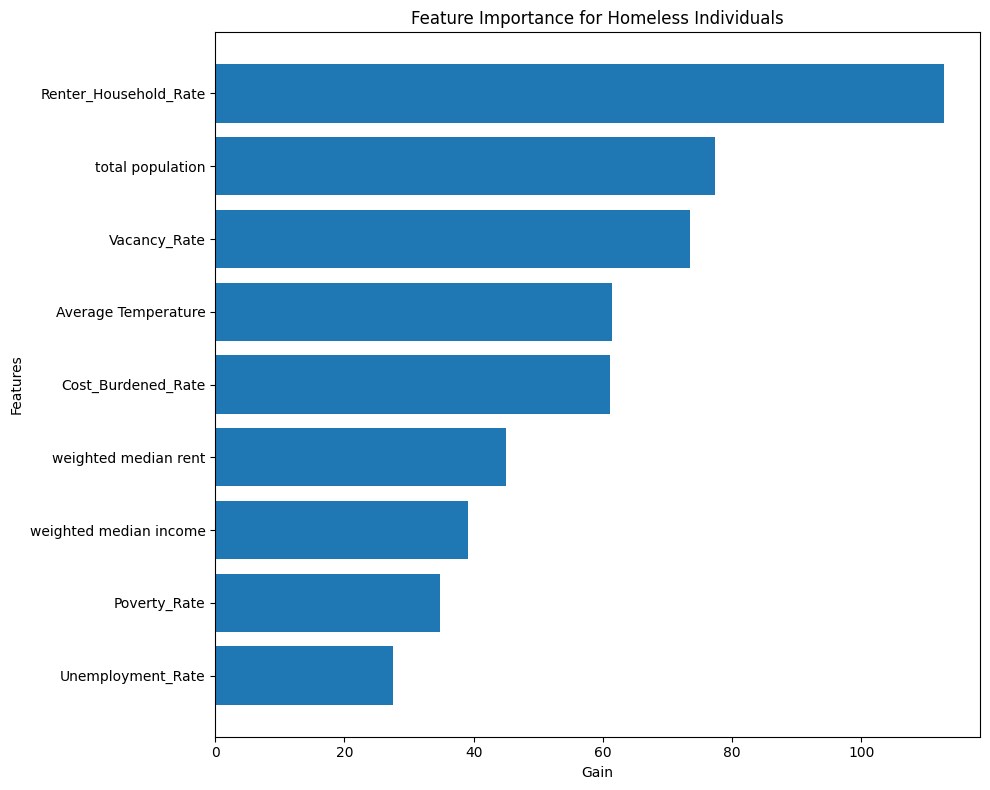

In [ ]:
# Feature Importance
gain_dict = best_model.get_booster().get_score(importance_type='gain')
gain_items = sorted(gain_dict.items(), key=lambda x: x[1])
feat_names, gain_values = zip(*gain_items)

plt.figure(figsize=(10, 8))
plt.barh(feat_names, gain_values)
plt.title("Feature Importance for Homeless Individuals")
plt.xlabel("Gain")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Homeless People in Families Model

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

features = [
    'weighted median income',
    'weighted median rent',
    'total population',
    'Poverty_Rate',
    'Vacancy_Rate',
    'Renter_Household_Rate',
    'Cost_Burdened_Rate',
    'Unemployment_Rate',
    'Average Temperature'
]
X = data[features]
y = data['Overall Homeless People in Families']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param_grid = {
    'n_estimators':      [100, 200, 500],
    'max_depth':         [2, 3],
    'learning_rate':     [0.01],
    'subsample':         [0.6, 0.8],
    'colsample_bytree':  [0.6, 0.8],
    'gamma':             [0, 1],
    'reg_alpha':         [0, 0.1, 1],
    'reg_lambda':        [1, 10]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse  = mean_squared_error(y_test,  y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse  = np.sqrt(test_mse)
train_mae  = mean_absolute_error(y_train, y_train_pred)
test_mae   = mean_absolute_error(y_test,  y_test_pred)
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)

print(f"Training Set MSE:       {train_mse:.2f}")
print(f"Training Set RMSE:      {train_rmse:.2f}")
print(f"Training Set MAE:       {train_mae:.2f}")
print(f"Training Set R-squared: {train_r2:.4f}")
print(f"Test Set MSE:           {test_mse:.2f}")
print(f"Test Set RMSE:          {test_rmse:.2f}")
print(f"Test Set MAE:           {test_mae:.2f}")
print(f"Test Set R-squared:     {test_r2:.4f}")


Training Set MSE:       0.30
Training Set RMSE:      0.55
Training Set MAE:       0.31
Training Set R-squared: 0.5356
Test Set MSE:           0.63
Test Set RMSE:          0.79
Test Set MAE:           0.38
Test Set R-squared:     0.3241


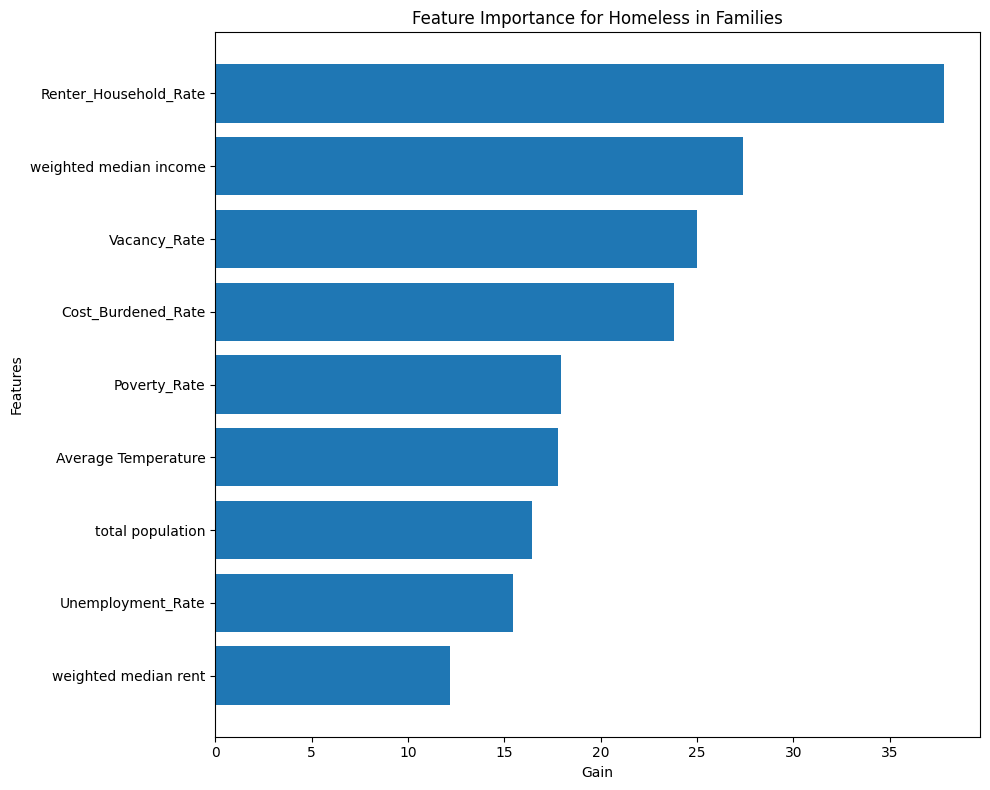

In [ ]:
# Feature Importance
gain_dict = best_model.get_booster().get_score(importance_type='gain')
gain_items = sorted(gain_dict.items(), key=lambda x: x[1])
feat_names, gain_values = zip(*gain_items)

plt.figure(figsize=(10, 8))
plt.barh(feat_names, gain_values)
plt.title("Feature Importance for Homeless in Families")
plt.xlabel("Gain")
plt.ylabel("Features")
plt.tight_layout()
plt.show()